In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import numpy as np
# import os
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import sys
sys.path.append("../")

In [ ]:
# Custom imports
from data_loader import load_and_split_data
from src.config_manager import read_config
from contingency_table import ct_x2, ct_x2_c2eq0


In [15]:
config = read_config("../config.yaml")
config

{'data': {'train_path': 'data/raw/train.csv',
  'test_path': 'data/raw/test.csv'},
 'base': {'RANDOM_SEED': 20},
 'modeling': {'TARGET_COLUMN': 'SalePrice', 'VALID_SIZE': 0.2},
 'hyperparameters': {'RIDGE_ALPHAS': [0.011, 0.1, 1.0, 10.0, 100.0],
  'LASSO_ALPHAS': [0.0001, 0.001, 0.01, 0.1, 1.0],
  'ELASTICNET_L1_RATIO': 0.5}}

In [16]:
# Load data
X_train, _, y_train, _ = load_and_split_data(config)

# Treatment of "False Nulls" (Imputation by Domain)

In [27]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class DomainImputer(BaseEstimator, TransformerMixin):
    """
    Transformador personalizado para manejar la imputación específica
    del dataset House Prices basada en reglas de dominio.
    """
    def __init__(self):
        # 1. Variables donde NaN significa "None" (Categoría 'No tiene')
        self.cols_none = [
            'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
            'BsmtFinType1', 'BsmtFinType2', 'Fence', 'FireplaceQu', 
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
            'PoolQC', 'MiscFeature'
        ]
        
        # 2. Variables donde NaN significa 0 (Numéricas)
        self.cols_zero = ['GarageYrBlt', 'MasVnrArea']
        
        # 3. Variables con Nulos reales (imputar con Moda)
        self.cols_mode = ['Electrical']
        
        # Diccionarios para guardar estadísticas aprendidas (evitar data leakage)
        self.lot_frontage_map = {} 
        self.electrical_mode = None
        self.masvnr_mode = None

    def fit(self, X, y=None):
        """Aprende las estadísticas del set de entrenamiento"""
        # Hacemos una copia ligera para no alterar el original en cálculos
        X_temp = X.copy()
        
        # A. Aprender la mediana de LotFrontage por Vecindario
        # Esto es más preciso que la media global
        self.lot_frontage_map = X_temp.groupby('Neighborhood')['LotFrontage'].median()
        
        # B. Aprender la moda de Electrical
        self.electrical_mode = X_temp['Electrical'].mode()[0]
        
        # C. Aprender la moda de MasVnrType (para el caso especial)
        self.masvnr_mode = X_temp['MasVnrType'].mode()[0]
        
        return self

    def transform(self, X):
        """Aplica las transformaciones a los datos"""
        X = X.copy() # Importante para no lanzar warnings de SettingWithCopy
        
        # 1. Imputación de "Falsos Nulos" Categóricos -> 'None'
        for col in self.cols_none:
            if col in X.columns:
                X[col] = X[col].fillna('None')

        # 2. Lógica Especial: MasVnrType
        # Si MasVnrArea > 0 pero Type es NaN, imputamos con Moda (es un dato perdido real)
        # Si MasVnrArea es 0 o NaN, Type es 'None' (no tiene revestimiento)
        if 'MasVnrType' in X.columns and 'MasVnrArea' in X.columns:
            # Caso complejo: Hay área pero no tipo -> Usar moda
            mask_real_missing = X['MasVnrType'].isna() & (X['MasVnrArea'] > 0)
            X.loc[mask_real_missing, 'MasVnrType'] = self.masvnr_mode
            
            # El resto de NaNs en MasVnrType son "No tiene"
            X['MasVnrType'] = X['MasVnrType'].fillna('None')

        # 3. Imputación de "Falsos Nulos" Numéricos -> 0
        for col in self.cols_zero:
            if col in X.columns:
                X[col] = X[col].fillna(0)
        
        # 4. Imputación Estadística (Electrical)
        if 'Electrical' in X.columns:
            X['Electrical'] = X['Electrical'].fillna(self.electrical_mode)

        # 5. Imputación Inteligente: LotFrontage
        # Rellenar con la mediana del vecindario. Si el vecindario es nuevo en Test
        # y no tiene mediana, se usa la mediana global como fallback.
        if 'LotFrontage' in X.columns and 'Neighborhood' in X.columns:
            # Mapeamos la mediana del vecindario
            neighborhood_medians = X['Neighborhood'].map(self.lot_frontage_map)
            # Rellenamos los nulos usando ese mapeo
            X['LotFrontage'] = X['LotFrontage'].fillna(neighborhood_medians)
            # Fallback: Si queda algún nulo (vecindario desconocido), usar mediana global
            X['LotFrontage'] = X['LotFrontage'].fillna(self.lot_frontage_map.median())
            
        return X

In [28]:
# --- PRUEBA DEL CÓDIGO ---
# Instanciamos el transformador
imputer = DomainImputer()

In [30]:
# Entrenamos y transformamos 

X_train_imputed = imputer.fit_transform(X_train)

In [33]:
pct_missing = X_train_imputed.isna().mean() * 100
missing_data = pd.DataFrame({'feature': X_train_imputed.columns, '% missing': pct_missing})
missing_data = missing_data[missing_data['% missing'] > 0].sort_values(by='feature', ascending=False)
missing_data.style.hide(axis="index").format({'% missing': '{:.2f}%'})

feature,% missing


# Handling Ordinal and Nominal Variables

In [34]:
from sklearn.preprocessing import OneHotEncoder

class FeatureEncoder(BaseEstimator, TransformerMixin):
    """
    Encargado de codificar variables categóricas:
    1. Ordinales: Mapeo manual respetando la jerarquía (Ex > Gd > TA...).
    2. Nominales: Se preparan para One-Hot Encoding (en este paso convertimos a string).
    """
    def __init__(self):
        # --- A. DEFINICIÓN DE MAPEOS ORDINALES ---
        
        # 1. Escala Estándar (Ex, Gd, TA, Fa, Po, None)
        # Aplica a: ExterQual, ExterCond, BsmtQual, BsmtCond, HeatingQC, 
        #           KitchenQual, FireplaceQu, GarageQual, GarageCond, PoolQC
        self.quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
        self.qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                          'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

        # 2. Basement Exposure (Gd > Av > Mn > No > None)
        self.bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
        
        # 3. Basement Finish (GLQ > ... > Unf > None)
        self.bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
        
        # 4. Garage Finish (Fin > RFn > Unf > None)
        self.garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
        
        # 5. Functional (Typ > ... > Sal)
        self.functional_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 
                               'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
        
        # 6. Fence (Privacidad > Madera/Alambre) - Criterio subjetivo pero útil
        self.fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}
        
        # 7. Driveway (Y > P > N)
        self.driveway_map = {'Y': 2, 'P': 1, 'N': 0}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        # --- 1. APLICAR MAPEOS ORDINALES ---
        
        # Mapeo General de Calidad
        for col in self.qual_cols:
            if col in X.columns:
                X[col] = X[col].map(self.quality_map)

        # Mapeos Específicos
        mappings = {
            'BsmtExposure': self.bsmt_exposure_map,
            'BsmtFinType1': self.bsmt_fin_map,
            'BsmtFinType2': self.bsmt_fin_map,
            'GarageFinish': self.garage_fin_map,
            'Functional': self.functional_map,
            'Fence': self.fence_map,
            'PavedDrive': self.driveway_map
        }
        
        for col, mapper in mappings.items():
            if col in X.columns:
                X[col] = X[col].map(mapper)
                
        # --- 2. TRATAMIENTO DE NOMINALES ---
        
        # CentralAir: Convertir Y/N a 1/0
        if 'CentralAir' in X.columns:
            X['CentralAir'] = X['CentralAir'].map({'Y': 1, 'N': 0})
            
        # MSSubClass: Es numérico pero representa categorías (20, 30, 40...)
        # Lo convertimos a string para que el OneHotEncoder lo detecte como categoría
        if 'MSSubClass' in X.columns:
            X['MSSubClass'] = X['MSSubClass'].astype(str)
            
        return X

In [37]:
# --- PRUEBA Y VISUALIZACIÓN EN SANDBOX ---

# 1. Instanciar encoder
encoder = FeatureEncoder()

# 2. Aplicar al set imputado (que obtuviste en el paso anterior)
# Asumimos que 'X_train_imputed' es tu DataFrame actual
X_train_encoded = encoder.fit_transform(X_train_imputed)

# 3. Separar para visualizar: ¿Qué columnas quedan como "object" (texto)?
# Estas son las NOMINALES puras que irán a One-Hot Encoding
nominal_cols = X_train_encoded.select_dtypes(include=['object']).columns.tolist()
ordinal_cols = X_train_encoded.select_dtypes(exclude=['object']).columns.tolist()

print(f"Variables Ordinales codificadas a numéricas: {len(ordinal_cols)}")
print(f"Variables Nominales listas para OHE: {len(nominal_cols)}")
print("-" * 30)
print("Ejemplo de Ordinal ('ExterQual'):\n", X_train_encoded['ExterQual'].value_counts().sort_index())
print("-" * 30)
print("Nominales restantes (Ejemplos):", nominal_cols[:5])

# 4. Check de Calidad: Ver correlación de las nuevas ordinales con el precio
# Esto confirma si tu mapeo tiene sentido (debería haber correlación positiva)
# Nota: Usamos np.log1p(y_train) porque el precio debe estar normalizado
correlation = X_train_encoded[encoder.qual_cols].corrwith(np.log1p(y_train))
print("\nCorrelación de Variables de Calidad con log(SalePrice):")
print(correlation.sort_values(ascending=False))

Variables Ordinales codificadas a numéricas: 54
Variables Nominales listas para OHE: 26
------------------------------
Ejemplo de Ordinal ('ExterQual'):
 ExterQual
2     12
3    720
4    392
5     44
Name: count, dtype: int64
------------------------------
Nominales restantes (Ejemplos): ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape']

Correlación de Variables de Calidad con log(SalePrice):
ExterQual      0.686642
KitchenQual    0.683401
BsmtQual       0.616565
FireplaceQu    0.552559
HeatingQC      0.485257
GarageQual     0.363857
GarageCond     0.354139
BsmtCond       0.296273
ExterCond      0.055151
PoolQC         0.038132
dtype: float64


# Ingeniería de Variables (Feature Creation)

In [39]:
class FeatureCreator(BaseEstimator, TransformerMixin):
    """
    Crea nuevas características de alto nivel combinando las existentes.
    Esto captura relaciones no lineales que el modelo lineal por sí solo no vería fácilmente.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        # 1. Total Square Feet (La variable rey)
        # Sumamos sótano + 1er piso + 2do piso
        # Si alguna es NaN (ya deberían estar en 0), usamos fillna(0) por seguridad
        X['TotalSF'] = (X['TotalBsmtSF'].fillna(0) + 
                        X['1stFlrSF'].fillna(0) + 
                        X['2ndFlrSF'].fillna(0))
        
        # 2. Total Bathrooms (Baños ponderados)
        # Baño completo vale 1, medio baño vale 0.5
        X['TotalBath'] = (X['FullBath'].fillna(0) + 
                          (0.5 * X['HalfBath'].fillna(0)) + 
                          X['BsmtFullBath'].fillna(0) + 
                          (0.5 * X['BsmtHalfBath'].fillna(0)))
        
        # 3. Antigüedad de la casa y Remodelación
        # HouseAge: Cuántos años tenía la casa cuando se vendió
        X['HouseAge'] = X['YrSold'] - X['YearBuilt']
        
        # RemodAge: Cuántos años pasaron desde la remodelación hasta la venta
        X['RemodAge'] = X['YrSold'] - X['YearRemodAdd']
        
        # HasRemodeled: ¿Fue remodelada alguna vez? (Binaria)
        X['HasRemodeled'] = (X['YearRemodAdd'] != X['YearBuilt']).astype(int)
        
        # Sanity Check: A veces YearBuilt > YrSold (datos erróneos), corregimos a 0
        X.loc[X['HouseAge'] < 0, 'HouseAge'] = 0
        X.loc[X['RemodAge'] < 0, 'RemodAge'] = 0
        
        return X



In [40]:
# --- PRUEBA EN SANDBOX ---
creator = FeatureCreator()
X_train_engineered = creator.fit_transform(X_train_encoded) # Usamos el output del paso anterior

# Verificamos la correlación de las nuevas variables con el precio
new_cols = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge', 'HasRemodeled']
print("Correlación de Nuevas Variables con log(SalePrice):")
print(X_train_engineered[new_cols].corrwith(np.log1p(y_train)).sort_values(ascending=False))

Correlación de Nuevas Variables con log(SalePrice):
TotalSF         0.766457
TotalBath       0.663115
HasRemodeled   -0.061150
RemodAge       -0.562687
HouseAge       -0.582194
dtype: float64


# Transformaciones Numéricas (Log-Transform)

In [42]:
from scipy.stats import skew

class SkewnessTransformer(BaseEstimator, TransformerMixin):
    """
    Identifica variables numéricas con alto sesgo (skewness) y les aplica
    una transformación logarítmica (log1p) para normalizarlas.
    """
    def __init__(self, skew_threshold=0.75):
        self.skew_threshold = skew_threshold
        self.skewed_features = [] # Guardaremos qué columnas transformamos

    def fit(self, X, y=None):
        # 1. Identificar solo columnas numéricas (excluyendo las binarias que creamos o dummies)
        # Nota: MSSubClass ya es string, así que no entrará aquí (correcto)
        numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
        numeric_features = X.select_dtypes(include=numerics).columns
        
        # 2. Calcular skewness
        skew_features = X[numeric_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
        
        # 3. Filtrar las que superan el umbral (e.g., > 0.75)
        # Excluimos variables "dummy" (0/1) porque log no tiene sentido ahí
        self.skewed_features = skew_features[abs(skew_features) > self.skew_threshold].index
        
        # Filtramos columnas binarias si se colaron (tienen solo 2 valores únicos)
        self.skewed_features = [col for col in self.skewed_features if X[col].nunique() > 2]
        
        return self

    def transform(self, X):
        X = X.copy()
        # Aplicar log1p (log(1+x)) a las columnas seleccionadas
        X[self.skewed_features] = np.log1p(X[self.skewed_features])
        return X



In [43]:
# --- PRUEBA EN SANDBOX ---
skew_transformer = SkewnessTransformer(skew_threshold=0.75)
skew_transformer.fit(X_train_engineered) # Aprende cuáles están sesgadas

print(f"Variables detectadas con sesgo alto: {len(skew_transformer.skewed_features)}")
print("Ejemplos:", skew_transformer.skewed_features[:5])

X_train_transformed = skew_transformer.transform(X_train_engineered)



Variables detectadas con sesgo alto: 35
Ejemplos: ['MiscVal', 'PoolQC', 'PoolArea', 'LotArea', '3SsnPorch']


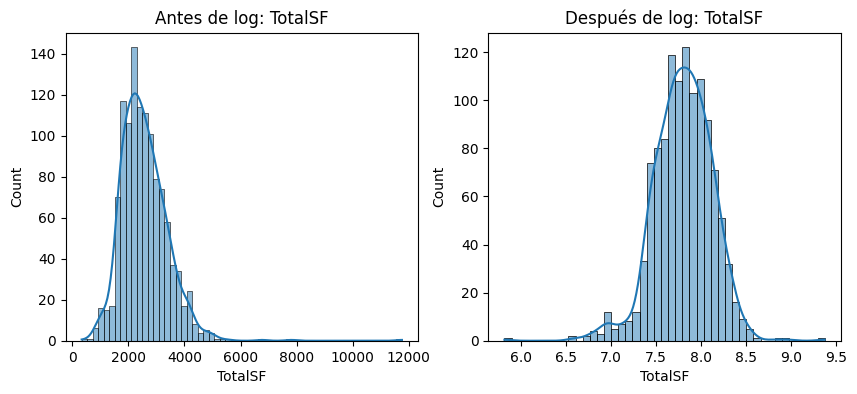

In [45]:
# Comparación visual
import matplotlib.pyplot as plt
import seaborn as sns

col_ejemplo = 'TotalSF' # O 'GrLivArea'
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(X_train_engineered[col_ejemplo], kde=True)
plt.title(f"Antes de log: {col_ejemplo}")

plt.subplot(1, 2, 2)
sns.histplot(X_train_transformed[col_ejemplo], kde=True)
plt.title(f"Después de log: {col_ejemplo}")
plt.show()

# Estandarización (Scaling)

In [48]:
from sklearn.preprocessing import StandardScaler

# 1. Preparación final antes del escalado
# En este punto, 'X_train_transformed' ya tiene:
# - Imputación hecha
# - Encoding hecho (variables ordinales a numéricas)
# - Feature Engineering hecho (TotalSF, etc.)
# - Log-transform hecho (Skewness corregido)

# PERO: Aún tenemos columnas 'object' (las Nominales como 'Neighborhood')
# El StandardScaler fallará si encuentra texto.
# Para el Sandbox, vamos a aplicar One-Hot Encoding rápido (get_dummies) para poder escalar todo.
# (En el script final de producción usaremos OneHotEncoder dentro del Pipeline, pero aquí queremos ver datos).

X_train_final_sandbox = pd.get_dummies(X_train_transformed)

print(f"Dimensiones antes de escalar: {X_train_final_sandbox.shape}")


Dimensiones antes de escalar: (1168, 246)


In [49]:
# 2. Aplicar StandardScaler
scaler = StandardScaler()

# Ajustamos (aprende media y desviación) y transformamos
X_train_scaled = scaler.fit_transform(X_train_final_sandbox)

# Ojo: StandardScaler devuelve un array de numpy, perdemos los nombres de columnas.
# Para visualizar, lo volvemos a convertir a DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, 
                                 columns=X_train_final_sandbox.columns, 
                                 index=X_train_final_sandbox.index)

# 3. Verificación de "Sanidad"
# Las medias deberían ser ~0 y las desviaciones estándar ~1
print("\n--- Verificación del Escalado ---")
print("Media de TotalSF (debe ser cercana a 0):", round(X_train_scaled_df['TotalSF'].mean(), 5))
print("Std Dev de TotalSF (debe ser cercana a 1):", round(X_train_scaled_df['TotalSF'].std(), 5))


--- Verificación del Escalado ---
Media de TotalSF (debe ser cercana a 0): 0.0
Std Dev de TotalSF (debe ser cercana a 1): 1.00043


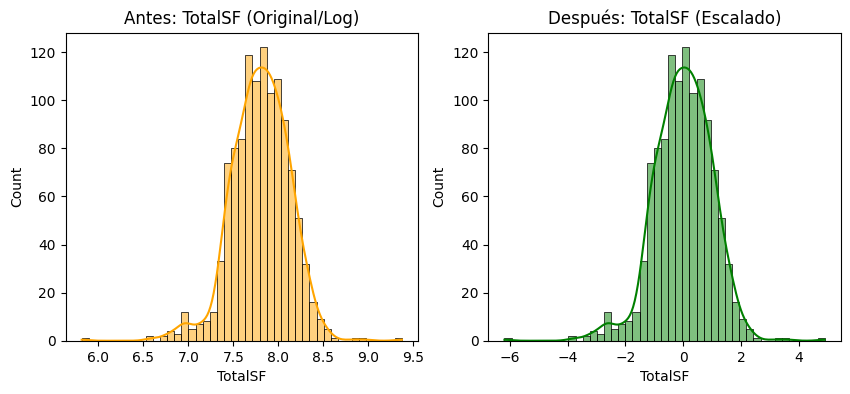

In [50]:
# Visualización rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(X_train_transformed['TotalSF'], kde=True, color='orange')
plt.title("Antes: TotalSF (Original/Log)")

plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled_df['TotalSF'], kde=True, color='green')
plt.title("Después: TotalSF (Escalado)")
plt.show()